In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2047446, 26)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Timestamp,...,Quarter,Weekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingStd_24,Difference,PctChange,Peak
0,16/12/2006,20:12:00,3.400,0.140,233.62,14.4,0.0,0.0,17.0,16/12/2006 20:12:00,...,4,1,3.410,3.380,4.216,3.286333,0.083777,-0.010,-0.002933,1
1,16/12/2006,20:13:00,3.400,0.140,233.64,14.4,0.0,0.0,17.0,16/12/2006 20:13:00,...,4,1,3.400,3.404,5.360,3.286167,0.083537,0.000,0.000000,1
2,16/12/2006,20:14:00,3.388,0.140,233.26,14.4,0.0,0.0,16.0,16/12/2006 20:14:00,...,4,1,3.400,3.378,5.374,3.286583,0.084038,-0.012,-0.003529,1
3,16/12/2006,20:15:00,3.370,0.086,233.90,14.4,0.0,0.0,17.0,16/12/2006 20:15:00,...,4,1,3.388,3.388,5.388,3.285833,0.083170,-0.018,-0.005313,1
4,16/12/2006,20:16:00,3.332,0.000,233.68,14.2,0.0,0.0,17.0,16/12/2006 20:16:00,...,4,1,3.370,3.376,3.666,3.284000,0.081565,-0.038,-0.011276,1


In [3]:
print(df.columns.tolist())

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Timestamp', 'Datetime', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'Weekend', 'Lag_1', 'Lag_24', 'Lag_168', 'RollingMean_24', 'RollingStd_24', 'Difference', 'PctChange', 'Peak']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047446 entries, 0 to 2047445
Data columns (total 26 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   Timestamp              str    
 10  Datetime               str    
 11  Hour                   int64  
 12  Day                    int64  
 13  Month                  int64  
 14  DayOfWeek              int64  
 15  Week                   int64  
 16  Quarter                int64  
 17  Weekend                int64  
 18  Lag_1                  float64
 19  Lag_24                 float64
 20  Lag_168                float64
 21  RollingMean_24         float64
 22  RollingStd_24          float6

In [5]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime").reset_index(drop=True)

print(df["Datetime"].min())
print(df["Datetime"].max())

2006-12-16 20:12:00
2010-11-26 21:02:00


In [6]:
features = [
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek",
    "Week",
    "Quarter",
    "Weekend",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "RollingMean_24",
    "RollingStd_24",
    "Difference",
    "PctChange"
]

target = "Global_active_power"

data = df[features + [target]].copy()

print(data.shape)

(2047446, 21)


In [7]:
train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

train_df = data[:train_size]
val_df = data[train_size:train_size + val_size]
test_df = data[train_size + val_size:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1433212, 21)
Validation: (307116, 21)
Test: (307118, 21)


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)

val_scaled = scaler.transform(val_df)

test_scaled = scaler.transform(test_df)

print("Scaling completed!")

Scaling completed!


In [9]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [10]:
window_size = 60
batch_size = 64

train_generator = TimeseriesGenerator(
    train_scaled[:, :-1],
    train_scaled[:, -1],
    length=window_size,
    batch_size=batch_size
)

val_generator = TimeseriesGenerator(
    val_scaled[:, :-1],
    val_scaled[:, -1],
    length=window_size,
    batch_size=batch_size
)

test_generator = TimeseriesGenerator(
    test_scaled[:, :-1],
    test_scaled[:, -1],
    length=window_size,
    batch_size=batch_size
)

In [11]:
model = Sequential([
    LSTM(
        64,
        input_shape=(window_size, len(features))
    ),

    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 1632s 73ms/step - loss: 8.3089e-04 - val_loss: 4.6352e-04
Epoch 2/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 1080s 48ms/step - loss: 6.0757e-04 - val_loss: 4.6134e-04
Epoch 3/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 1093s 49ms/step - loss: 5.8943e-04 - val_loss: 4.4902e-04


In [14]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

In [15]:
print(history.history)

{'loss': [0.0008308929391205311, 0.0006075726123526692, 0.0005894270725548267], 'val_loss': [0.0004635184595827013, 0.00046134123113006353, 0.00044902003719471395]}


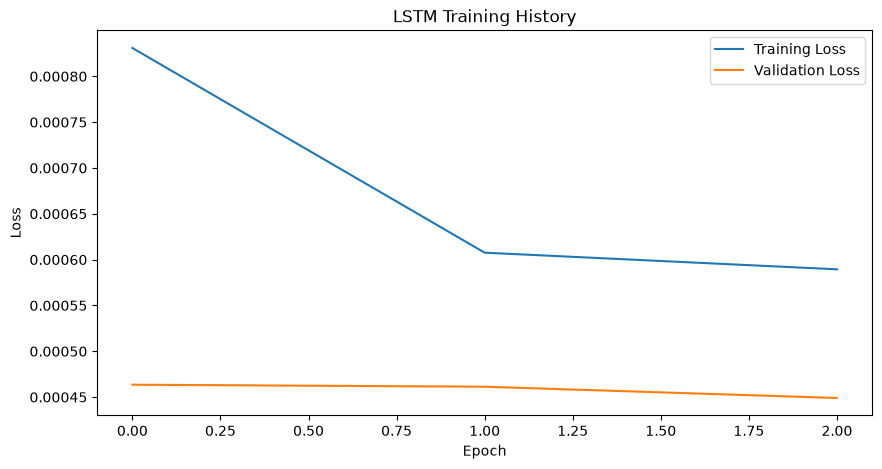

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

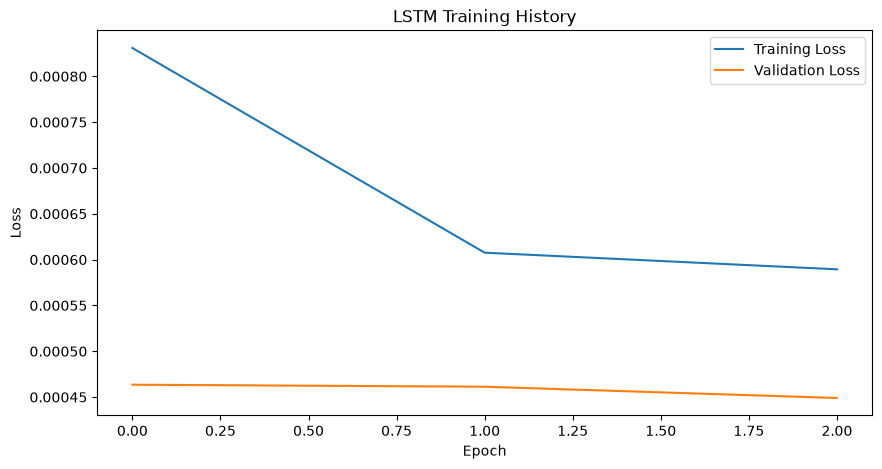

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig("../reports/figures/lstm_training_history.png",
            bbox_inches="tight")

plt.show()

In [18]:
predictions = model.predict(test_generator)

print(predictions.shape)

4798/4798 ━━━━━━━━━━━━━━━━━━━━ 88s 18ms/step
(307058, 1)


In [19]:
y_true = []

for _, y in test_generator:
    y_true.extend(y)

y_true = np.array(y_true)

print(y_true.shape)

(307058,)


In [20]:
y_pred = predictions.flatten()

print(y_pred.shape)

(307058,)


In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

r2 = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R²  :", r2)

MAE : 0.008236666568425697
RMSE: 0.01895424694530049
MAPE: 16.642518350042607
R²  : 0.9409578468766884


In [22]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R2"],
    "Value": [mae, rmse, mape, r2]
})

metrics_df

,Metric,Value
0,MAE,0.008237
1,RMSE,0.018954
2,MAPE,16.642518
3,R2,0.940958


In [23]:
metrics_df.to_csv(
    "../reports/lstm_metrics.csv",
    index=False
)

In [24]:
model.save("../models/lstm_model.keras")

print("Model saved ")

Model saved 


<module 'matplotlib.pyplot' from 'c:\\Users\\abc\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\matplotlib\\pyplot.py'>

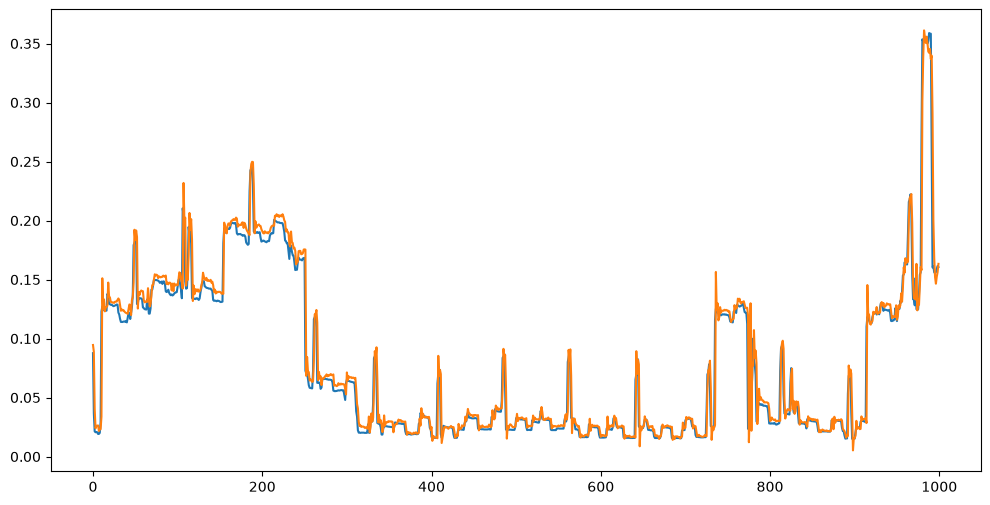

In [25]:
plt.figure(figsize=(12,6))

plt.plot(y_true[:1000], label="Actual")
plt.plot(y_pred[:1000], label="Predicted")

plt

In [26]:
predictions_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred
})

predictions_df.to_csv(
    "../reports/lstm_predictions.csv",
    index=False
)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

tuned_model = Sequential([
    LSTM(
        128,
        input_shape=(window_size, len(features))
    ),

    Dropout(0.3),

    Dense(1)
])

tuned_model.compile(
    optimizer="adam",
    loss="mse"
)

tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,417 (298.50 KB)

 Trainable params: 76,417 (298.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [29]:
tuned_history = tuned_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2337s 104ms/step - loss: 8.3671e-04 - val_loss: 4.8977e-04
Epoch 2/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2282s 102ms/step - loss: 6.1146e-04 - val_loss: 4.6375e-04
Epoch 3/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2331s 104ms/step - loss: 5.9037e-04 - val_loss: 4.5541e-04


In [30]:
tuned_predictions = tuned_model.predict(test_generator)

tuned_y_pred = tuned_predictions.flatten()

4798/4798 ━━━━━━━━━━━━━━━━━━━━ 196s 41ms/step


In [31]:
tuned_mae = mean_absolute_error(y_true, tuned_y_pred)

tuned_rmse = np.sqrt(
    mean_squared_error(y_true, tuned_y_pred)
)

tuned_mape = np.mean(
    np.abs((y_true - tuned_y_pred) / y_true)
) * 100

tuned_r2 = r2_score(
    y_true,
    tuned_y_pred
)

print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("MAPE:", tuned_mape)
print("R²  :", tuned_r2)

MAE : 0.007717326620401707
RMSE: 0.018970559835480436
MAPE: 13.91412643678454
R²  : 0.9408561743990315


In [32]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline LSTM", "Tuned LSTM"],
    "MAE": [mae, tuned_mae],
    "RMSE": [rmse, tuned_rmse],
    "MAPE": [mape, tuned_mape],
    "R2": [r2, tuned_r2]
})

comparison_df

,Model,MAE,RMSE,MAPE,R2
0,Baseline LSTM,0.008237,0.018954,16.642518,0.940958
1,Tuned LSTM,0.007717,0.018971,13.914126,0.940856


In [33]:
comparison_df.to_csv(
    "../reports/lstm_model_comparison.csv",
    index=False
)

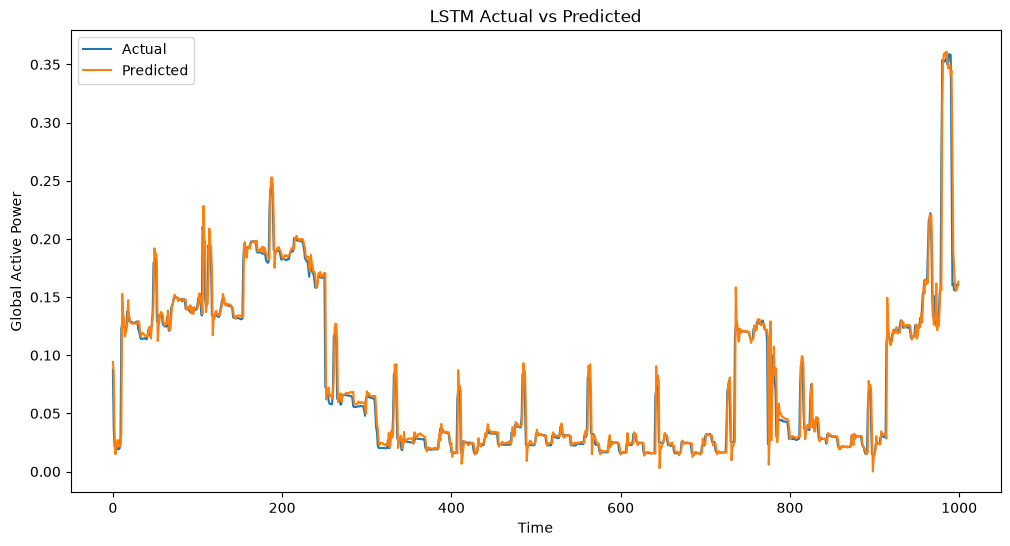

In [34]:
plt.figure(figsize=(12,6))

plt.plot(y_true[:1000], label="Actual")
plt.plot(tuned_y_pred[:1000], label="Predicted")

plt.title("LSTM Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.legend()

plt.savefig(
    "../reports/figures/lstm_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()